# Ejercicio 3

**Consigna:**

En lo que sigue, consideraremos que la variable protegida a analizar será **género**.
Basándonos en trabajos que señalan ciertos sesgos de género, se propone:

a) Describir con palabras cómo se interpretan en este contexto los criterios de fairness vistos en clase: Statistical Parity, Equalized Odds, Equal Opportunity y Predictive Parity.

b) Considerando como medida de disparidad el módulo de la diferencia y seleccionando un umbral definido por ustedes, analizar si el modelo inicial es fair para cada una de las posibles definiciones de fairness estudiadas en el inciso anterior.

c) Recordando que forman parte de la entidad asignada en cada conjunto de datos, ¿cuál de los criterios de fairness le parece relevante en este contexto? Justificar su elección.

---
## Nota sobre el enfoque

El dataset de Bank Marketing **no tiene variable de género**. Como establecimos en el Ej1, usamos **job como proxy de género** (los trabajos housemaid y dmin. fueron históricamente femeninos).

El ejercicio analiza la fairness del modelo usando este proxy de género.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico al Ej2 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])  # data leakage
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

# DataFrame de análisis
test_idx = X_test.index
df_analysis = pd.DataFrame({
    'job': df_original.loc[test_idx, 'job'].values,
    'y_true': y_test.values,
    'y_pred': y_pred
})

# Proxy de género
df_analysis['job_group'] = df_analysis['job'].apply(
    lambda x: 'hist_femenino' if x in ['housemaid', 'admin.'] else 'hist_masculino_otro'
)

print('Pipeline cargado. Modelo entrenado.')
print(f'Test: {len(df_analysis)} registros')

Pipeline cargado. Modelo entrenado.
Test: 9043 registros


In [4]:
def calcular_metricas_fairness(df_grupo):
    """Calcula las métricas de fairness para un grupo."""
    yt = df_grupo['y_true']
    yp = df_grupo['y_pred']
    
    # Statistical Parity: P(Y_pred=1 | grupo)
    stat_parity = yp.mean()
    
    # Equal Opportunity (TPR): P(Y_pred=1 | Y=1, grupo)
    tpr = recall_score(yt, yp, zero_division=0)
    
    # Predictive Parity (Precision): P(Y=1 | Y_pred=1, grupo)
    prec = precision_score(yt, yp, zero_division=0)
    
    # FPR para Equalized Odds: P(Y_pred=1 | Y=0, grupo)
    fp = ((yt == 0) & (yp == 1)).sum()
    tn = ((yt == 0) & (yp == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    return pd.Series({
        'Statistical Parity': stat_parity,
        'Equal Opportunity (TPR)': tpr,
        'Predictive Parity (Precision)': prec,
        'TPR (Equalized Odds)': tpr,
        'FPR (Equalized Odds)': fpr
    })

print('Funciones de fairness definidas.')

Funciones de fairness definidas.


---
# PARTE 1: `job` como proxy de género

Grupos: **hist_femenino** (`housemaid`, `admin.`) vs. **hist_masculino_otro** (resto)

## a) Criterios de fairness en contexto (proxy de género via `job`)

1. **Statistical Parity**: El modelo predice suscripción en **igual proporción** para empleos históricamente femeninizados que para los demás. Es decir, si predecimos que el 10% de las personas en dichos trabajos se suscribirán, deberíamos predecir lo mismo para el otro grupo. No importa si realmente se suscriben o no.

2. **Equal Opportunity**: Dado que el objetivo del banco es encontrar suscriptores, queremos que entre las personas que **sí se iban a suscribir**, el modelo las detecte igual de bien sin importar si tienen un trabajo históricamente femeninizado o no. Es decir, el **Recall (TPR)** debe ser similar entre grupos.

3. **Equalized Odds**: Más exigente que Equal Opportunity. Pide que tanto el TPR como el FPR sean iguales entre grupos. En nuestro contexto, además de detectar igual proporción de verdaderos suscriptores, queremos que la tasa de 'falsas alarmas' (llamar a alguien que no se suscribirá) sea similar. Esto es relevante porque si llamamos innecesariamente más a un grupo, estamos generando una molestia desproporcionada.

4. **Predictive Parity**: Cuando el modelo dice 'esta persona se suscribe', la **confianza** (Precisión) de esa predicción debe ser igual para ambos grupos. Es decir, si predecimos que alguien en un trabajo femeninizado se suscribirá, la probabilidad de que realmente lo haga debe ser la misma que para el otro grupo.

> **Nota teórica: incompatibilidad de los criterios de fairness**
>
> Un resultado fundamental en la teoría de equidad algorítmica (Chouldechova, 2017; Kleinberg et al., 2017) demuestra que, cuando las **tasas base de la clase positiva difieren entre grupos** (es decir, cuando la proporción de suscriptores varía entre grupos demográficos), es **matemáticamente imposible** satisfacer simultáneamente Statistical Parity, Equal Opportunity y Predictive Parity.
>
> En nuestro dataset esto se verifica claramente: la tasa de suscripción (`y=yes`) no es igual entre empleos históricamente femeninizados y el resto, ni entre los distintos estados civiles. Por lo tanto, **debemos elegir** qué criterio priorizar según el contexto del problema — no existe una solución que satisfaga todos a la vez.
>
> Esta es la razón por la cual el inciso **c)** pide justificar la elección de un único criterio relevante.
>
> *Referencia: Chouldechova, A. (2017). Fair prediction with disparate impact: A study of bias in recidivism prediction instruments. Big Data, 5(2), 153-163.*

## b) Análisis cuantitativo de fairness (proxy de género)

Usamos como medida de disparidad el **módulo de la diferencia** entre las métricas de ambos grupos. Seleccionamos un **umbral de 0.1** (10%), una elección estándar en la literatura de fairness.

--- Métricas de Fairness por Grupo (job) ---
                     Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  TPR (Equalized Odds)  FPR (Equalized Odds)
Grupo                                                                                                                                      
hist_femenino                  0.038186                 0.184932                       0.562500              0.184932              0.018902
hist_masculino_otro            0.038017                 0.205044                       0.631757              0.205044              0.015857

--- Disparidades (umbral = 0.1) ---
Statistical Parity: 0.0002 → ✅ FAIR
Equal Opportunity (TPR): 0.0201 → ✅ FAIR
Predictive Parity (Precision): 0.0693 → ✅ FAIR
TPR (Equalized Odds): 0.0201 → ✅ FAIR
FPR (Equalized Odds): 0.0030 → ✅ FAIR


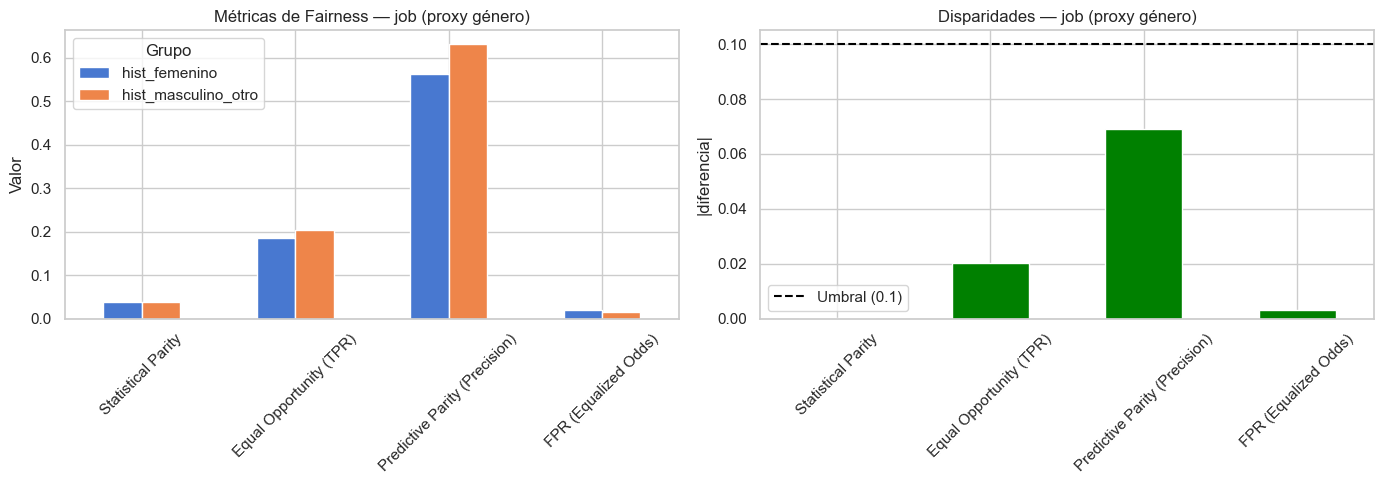

In [6]:
# Calcular métricas por grupo (job)
grupos_job = ['hist_femenino', 'hist_masculino_otro']
metricas_job = {}
for grupo in grupos_job:
    mask = df_analysis['job_group'] == grupo
    metricas_job[grupo] = calcular_metricas_fairness(df_analysis[mask])

df_metricas_job = pd.DataFrame(metricas_job).T
df_metricas_job.index.name = 'Grupo'

print('--- Métricas de Fairness por Grupo (job) ---')
print(df_metricas_job.to_string())
print()

# Disparidades
disparidad_job = (df_metricas_job.loc['hist_femenino'] - df_metricas_job.loc['hist_masculino_otro']).abs()
umbral = 0.1

print(f'--- Disparidades (umbral = {umbral}) ---')
for metrica, valor in disparidad_job.items():
    fair = '✅ FAIR' if valor < umbral else '❌ NO FAIR'
    print(f'{metrica}: {valor:.4f} → {fair}')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métricas por grupo
df_metricas_job[['Statistical Parity', 'Equal Opportunity (TPR)', 
                  'Predictive Parity (Precision)', 'FPR (Equalized Odds)']].T.plot(
    kind='bar', ax=axes[0]
)
axes[0].set_title('Métricas de Fairness — job (proxy género)')
axes[0].set_ylabel('Valor')
axes[0].legend(title='Grupo')
axes[0].tick_params(axis='x', rotation=45)

# Disparidades vs umbral
disp_plot = disparidad_job[['Statistical Parity', 'Equal Opportunity (TPR)',
                             'Predictive Parity (Precision)', 'FPR (Equalized Odds)']]
colors = ['green' if v < umbral else 'red' for v in disp_plot.values]
disp_plot.plot(kind='bar', ax=axes[1], color=colors)
axes[1].axhline(y=umbral, color='black', linestyle='--', label=f'Umbral ({umbral})')
axes[1].set_title('Disparidades — job (proxy género)')
axes[1].set_ylabel('|diferencia|')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# 1. Base rates reales por grupo
print("=== BASE RATES ===")
for grupo in grupos_job:
    mask = df_analysis['job_group'] == grupo
    sub = df_analysis[mask]
    print(f"{grupo}:")
    print(f"  Cantidad= {len(sub)}, base rate= {sub['y_true'].mean():.4f}")



# 3. Reducir el umbral y ver qué pasa
for umbral_test in [0.05, 0.03, 0.01]:
    print(f"\n=== Umbral = {umbral_test} ===")
    for metrica, valor in disparidad_job.items():
        fair = '✅' if valor < umbral_test else '❌'
        print(f"  {metrica}: {valor:.4f} → {fair}")

=== BASE RATES ===
hist_femenino:
  Cantidad= 1257, base rate= 0.1161
hist_masculino_otro:
  Cantidad= 7786, base rate= 0.1171

=== Umbral = 0.05 ===
  Statistical Parity: 0.0002 → ✅
  Equal Opportunity (TPR): 0.0201 → ✅
  Predictive Parity (Precision): 0.0693 → ❌
  TPR (Equalized Odds): 0.0201 → ✅
  FPR (Equalized Odds): 0.0030 → ✅

=== Umbral = 0.03 ===
  Statistical Parity: 0.0002 → ✅
  Equal Opportunity (TPR): 0.0201 → ✅
  Predictive Parity (Precision): 0.0693 → ❌
  TPR (Equalized Odds): 0.0201 → ✅
  FPR (Equalized Odds): 0.0030 → ✅

=== Umbral = 0.01 ===
  Statistical Parity: 0.0002 → ✅
  Equal Opportunity (TPR): 0.0201 → ❌
  Predictive Parity (Precision): 0.0693 → ❌
  TPR (Equalized Odds): 0.0201 → ❌
  FPR (Equalized Odds): 0.0030 → ✅


## c) ¿Cuál criterio de fairness es más relevante? (proxy de género)

En el contexto de marketing bancario donde el objetivo es **incrementar la tasa de suscripción**, consideramos que el criterio más relevante es **Equal Opportunity**.

### Justificación:

1. **Alineación con el objetivo de negocio**: Nos interesa que entre las personas que **realmente se habrían suscrito**, el modelo las identifique con la misma probabilidad sin importar su tipo de trabajo (y por extensión, su género inferido). No queremos que el banco pierda más suscriptores potenciales de un grupo que de otro.

2. **Coherencia con el inciso b del Ej2**: Identificamos al Falso Negativo como el error más crítico. Equal Opportunity mide exactamente si la tasa de FN es equitativa entre grupos, ya que un TPR más bajo = más FN.

3. **Statistical Parity no es lo ideal** porque no distingue entre predicciones correctas e incorrectas. Si un grupo efectivamente tiene mayor tasa de suscripción, forzar paridad estadística sería contraproducente.

4. **Equalized Odds es demasiado exigente** para este contexto. Si bien igualar el FPR es deseable (no molestar desproporcionadamente a un grupo con llamadas innecesarias), el costo de un FP es marginal comparado con el de un FN. Priorizamos detectar suscriptores.

5. **Predictive Parity es secundaria**: la confianza de la predicción importa, pero es menos crítica que asegurar que no se pierdan suscriptores de ningún grupo.